In [1]:
!pip install -q xgboost lightgbm psutil

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import psutil

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

OUTPUT_DIR = "/kaggle/working/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
DATA_PATH = "/kaggle/input/datasets/avimistryy/i-elective-poster/df_kwh_adjusted.csv"

df = pd.read_csv(DATA_PATH, sep=';')

print("Shape:", df.shape)

# Timestamp column
timestamp_col = df.columns[0]

# Meter columns
meter_cols = df.columns[1:]

# Convert to numeric
df[meter_cols] = df[meter_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# Total grid load
total_load = df[meter_cols].sum(axis=1)

features = pd.DataFrame()

features["load"] = total_load
features["lag_1"] = total_load.shift(1)
features["lag_4"] = total_load.shift(4)
features["lag_24"] = total_load.shift(24)

features["rolling_mean_24"] = (
    total_load.rolling(24).mean()
)

features["rolling_std_24"] = (
    total_load.rolling(24).std()
)

features.dropna(inplace=True)

print(features.head())
print(features.shape)

Shape: (140256, 371)
       load    lag_1    lag_4  lag_24  rolling_mean_24  rolling_std_24
24  3134.25  3165.50     0.00   132.0      2075.729167     1719.741210
25   301.75  3134.25  3074.00  2856.5      1969.281250     1748.144075
26   134.50   301.75   295.75   102.0      1970.635417     1746.646678
27   345.25   134.50  3165.50   304.0      1972.354167     1744.954833
28    19.50   345.25  3134.25    49.5      1971.104167     1746.402305
(140232, 6)


In [3]:
X = features.drop(
    columns=["load"]
)

y = features["load"]

split_idx = int(
    len(X) * 0.80
)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(X_train.shape)
print(X_test.shape)

(112185, 5)
(28047, 5)


In [4]:
sizes = [0.2,0.4,0.6,0.8,1.0]

results = []

for size in sizes:

    sample_size = int(
        len(X_train) * size
    )

    X_sub = X_train.iloc[:sample_size]
    y_sub = y_train.iloc[:sample_size]

    model = LGBMRegressor(
        random_state=42
    )

    start = time.time()

    model.fit(
        X_sub,
        y_sub
    )

    preds = model.predict(
        X_test
    )

    runtime = time.time()-start

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    carbon = runtime * sample_size

    results.append([
        int(size*100),
        rmse,
        runtime,
        carbon
    ])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 22437, number of used features: 5
[LightGBM] [Info] Start training from score 2959.270145
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 44874, number of used features: 5
[LightGBM] [Info] Start training from score 4837.428751
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 67311, number of used features: 5
[LightGBM] [Info] Start 

In [5]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Dataset_Size",
        "RMSE",
        "Runtime",
        "Carbon"
    ]
)

results_df.to_csv(
    f"{OUTPUT_DIR}/RQ4_Table.csv",
    index=False
)

display(results_df)

,Dataset_Size,RMSE,Runtime,Carbon
0,20,15483.031967,0.270698,6073.652608
1,40,7437.210884,0.273483,12272.267146
2,60,3513.899478,0.330063,22216.845539
3,80,3406.402612,0.404478,36301.076709
4,100,3358.897660,0.523078,58681.474732


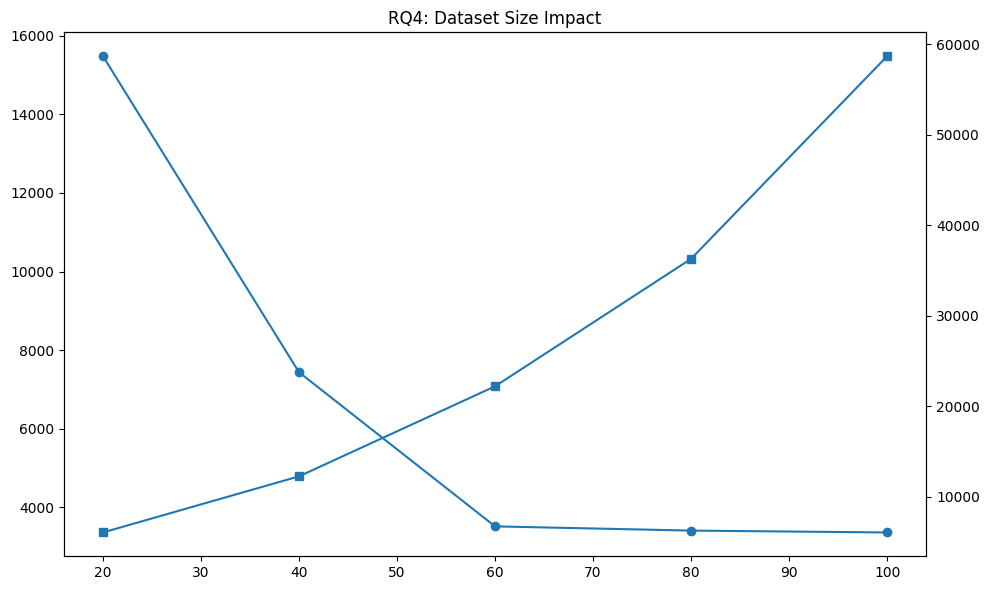

In [6]:
fig, ax1 = plt.subplots(
    figsize=(10,6)
)

ax1.plot(
    results_df["Dataset_Size"],
    results_df["RMSE"],
    marker="o"
)

ax2 = ax1.twinx()

ax2.plot(
    results_df["Dataset_Size"],
    results_df["Carbon"],
    marker="s"
)

plt.title(
    "RQ4: Dataset Size Impact"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/RQ4_Figure.pdf"
)

plt.show()